<div style="
    background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
    border-radius: 16px;
    padding: 48px 40px 40px 40px;
    margin-bottom: 8px;
    text-align: center;
    box-shadow: 0 8px 32px rgba(0,0,0,0.3);
">
    <h1 style="
        color: #e2e8f0;
        font-size: 2.2em;
        font-weight: 700;
        margin: 0 0 12px 0;
        letter-spacing: 0.5px;
    ">Rozwinięcia ortogonalne w przetwarzaniu i kompresji obrazów</h1>
    <p style="
        color: #94a3b8;
        font-size: 1.05em;
        margin: 0;
        letter-spacing: 1px;
        text-transform: uppercase;
    ">DCT · FFT · SFT — Implementacja i analiza porównawcza</p>
</div>

<style>
/* ── Global notebook theme ── */
.jp-MarkdownOutput h2 {
    color: #1e3a5f;
    font-size: 1.6em;
    font-weight: 700;
    border-bottom: 3px solid #3b82f6;
    padding-bottom: 6px;
    margin-top: 40px;
    margin-bottom: 16px;
}
.jp-MarkdownOutput h3 {
    color: #1e3a5f;
    font-size: 1.2em;
    font-weight: 600;
    border-left: 4px solid #60a5fa;
    padding-left: 10px;
    margin-top: 28px;
    margin-bottom: 10px;
}
.jp-MarkdownOutput h4 {
    color: #334155;
    font-weight: 600;
    margin-top: 18px;
}
.jp-MarkdownOutput p {
    line-height: 1.75;
    color: #334155;
}
.jp-MarkdownOutput ol, .jp-MarkdownOutput ul {
    line-height: 1.9;
    color: #334155;
}
.jp-MarkdownOutput strong { color: #1e40af; }
.jp-MarkdownOutput em { color: #475569; }
.jp-CodeCell .jp-Cell-inputWrapper {
    border-left: 3px solid #3b82f6 !important;
}
</style>

<div style="background:#f0f9ff; border-left:5px solid #0ea5e9; border-radius:8px; padding:20px 24px; margin:8px 0;">

## Cel i zakres projektu

### Cel projektu
Celem projektu jest implementacja ortogonalnych algorytmów kompresji obrazów **DCT i SFT**, oraz porównanie ich i wizualizacja efektów kompresji obrazów.

### Możliwe zastosowania
1. Wykorzystanie kompresji w celu przesyłania mniejszej ilości danych np. w komunikatorach tekstowych.
2. Nauka modeli ML z wykorzystaniem skompresowanych danych, aby ograniczyć dane wejściowe i przyśpieszyć czas uczenia.

</div>

## Wstęp teoretyczny

### Ortogonalność
To pojęcia, które opisuje wektory znajdujące się w przestrzeni unitarnej. Ortogonalność oznacza, że wektory są prostopadłe wobec siebie i ich iloczyn sklarny wynosi 0.
Układ jest ortogonalny, jeżeli jego wszystkie elementy są ortogonalne. 
$$\langle x, y \rangle = 0 \quad \langle x, y \rangle = \|x\| \cdot \|y\| \cdot \cos(\theta)$$

#### **Ortogonalność w DCT**
<p style='text-align: justify;'>Ortogonalność w <b>DCT</b> oznacza, że wszystkie wiersze i kolumny w macierzy transformacji są ortogonalne co oznacza, że iloczyn skalarny między parą różnych wierszy lub kolumn wynosi 0. Wynikiem operacji mnożenia macierzy ($T \cdot T^T$) jest macierz jednostkowa ($I$), jej iloczyn skalarny wiersza z samym sobą wynosi 1, czyli wiersze macierzy są znormalizowane (mają długość jednostkową). Dowodzi to, że macierz ($T$) jest ortonormalna. Pozwala to na implementację algorytmu z wykorzystaniem tylko jednej macierzy transformacji, ponieważ jej transpozycja pozwala na transformacje z wymiaru wierszy na wymiar kolumn (<i>Zaimplentowany algorytm początkowo wykonuje przekształcenie wartości na częstotliwości w wymiarze kolumn macierzy, a następnie w wymiarze wierszy</i>). Upraszcza to drastycznie operacje obliczeniową transformaty odwrotnej <b>IDCT</b>.</p>

#### **Ortogonalność w SFT**
<p style='text-align: justify;'>W przypadku SFT ortogonalność odgrywa rolę zbliżoną do klasycznej transformaty Fouriera, jednak z istotnym zastrzeżeniem wynikającym z natury algorytmu. SFT bazuje na założeniu, że analizowany sygnał jest rzadki (ang. sparse) w dziedzinie częstotliwości, co oznacza, że tylko niewielka liczba współczynników fourierowskich ma znaczącą wartość. Choć bazowe funkcje transformaty pozostają ortogonalne, algorytm SFT wykorzystuje techniki rzutowania sygnału na podprzestrzenie o niższym wymiarze poprzez filtry pasmowe lub operacje mieszania (hashingu) częstotliwości. Pozwala to na identyfikację dominujących składowych bez konieczności obliczania pełnego spektrum, co drastycznie redukuje złożoność obliczeniową przy zachowaniu matematycznej spójności wynikającej z ortogonalności bazy sinusów i cosinusów.</p>

### Algorytm DCT
<p style='text-align: justify;'> Transormacja <b>DCT</b> polega na zamianie elementów z domeny przestrzennej na domenę częstotliwościową. Ortogononalność jest podstawowym paradygmatem tej transformaty, ponieważ pozwala na podział obrazu z pikseli na określoną ilość niezależnych od siebie częstotliwości. DCT jest oparte o operacje trygonometryczne cosinus. Wynikiem transformaty jest macierz, w której lewym górnym rogu znajdują się niskie częstotliwości (średni kolor piksela, przejścia), a prawym dolnym rogu wysokie częstotliwości (szumy, detale). Kompresja obrazu jest możliwa, ponieważ "pozbycie się" wysokich częstotliwości, których widoczność jest ograniczona dla ludzkiego oka w nieznacznym stopniu obniża jakość obrazu, formalną nazwą tej operacji jest kwantyzacja. Kompresja DCT jest kompresją stratną, co oznacza, że po odwróceniu transformacji <b>DCT</b>, część informacji jest bezpowrotnie utracona. Za utrate informacji odpowiedzialna jest kwantyzacji czyli operacja "przycinania wysokich częstotliwość".</p>

### Algorytm FFT
<p style='text-align: justify;'>Transformacja FFT polega na zamianie elementów z domeny przestrzennej na domenę częstotliwościową przy użyciu liczb zespolonych. Głównym paradygmatem tej transformaty jest rozkład obrazu na sumę funkcji sinusoidalnych o różnej amplitudzie i fazie. Wynikiem transformacji jest macierz współczynników, gdzie najsilniejsze wartości (niskie częstotliwości) niosą kluczowe informacje o kształtach, a słabsze (wysokie częstotliwości) odpowiadają za detale i szumy. Kompresja jest możliwa dzięki zastosowaniu progowania (thresholding) – wszystkie składowe o amplitudzie mniejszej niż zadana wartość $M$ są zerowane. Operacja ta jest formą kwantyzacji, która w znacznym stopniu ogranicza ilość danych przy niewielkim spadku jakości widocznej dla oka. Podobnie jak w przypadku DCT, po wykonaniu odwrotnej transformacji (IFFT) część informacji jest bezpowrotnie utracona, co czyni ten proces metodą kompresji stratnej.</p>

### Algorytm SFT
<p style='text-align: justify;'>Transformacja SFT (Sparse Fourier Transform) to zoptymalizowana wersja analizy fourierowskiej, zaprojektowana dla sygnałów, których reprezentacja w dziedzinie częstotliwości jest zdominowana przez nieliczne, istotne składowe. Podczas gdy tradycyjne FFT przetwarza wszystkie N punktów danych, SFT przeszukuje widmo w poszukiwaniu najsilniejszych częstotliwości, ignorując składowe o pomijalnej amplitudzie już na etapie obliczeń. Proces ten opiera się na próbkowaniu sygnału w sposób, który celowo wywołuje zjawisko aliasingu w kontrolowanych warunkach, co pozwala na szybką lokalizację energetycznych maksimów. Kompresja w SFT jest naturalnym następstwem samej natury transformaty – algorytm z założenia wyodrębnia jedynie k najważniejszych współczynników, co stanowi formę automatycznej selekcji informacji. Jest to metoda stratna, ponieważ pominięte składowe, często utożsamiane z szumem tła, nie są uwzględniane w procesie rekonstrukcji. Pozwala to na osiągnięcie ogromnych oszczędności mocy obliczeniowej i pamięci przy zachowaniu kluczowych cech strukturalnych sygnału.</p>

---
## Omówienie kodu aplikacji

### Wykorzystane biblioteki

| Biblioteka | Rola w projekcie |
|---|---|
| **Scikit-image** | Wczytywanie obrazów; gotowe funkcje DCT |
| **Matplotlib** | Generowanie wykresów i wizualizacji |
| **NumPy** | Obliczenia numeryczne i operacje macierzowe |
| **SciPy** | Implementacja referencyjna DCT (wersja podstawowa) |

In [1]:
import timeit
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import skimage.io as io
import skimage.color as color
from scipy.fftpack import dct, idct
from utils import time_measure, image, visualizations
from algorithms import dct, dct_format, fft, sft

### Zmienne globalne

| Zmienna | Opis |
|---|---|
| `dct_block_size` | Rozmiar pojedynczego bloku przetwarzanego przez DCT (domyślnie $8 \times 8$) |
| `path` | Ścieżka do obrazu poddawanego kompresji |
| `files_path` | Ścieżka do katalogu zawierającego wszystkie modele testowe |

In [2]:
dct_block_size = 64
path = "test_models/test_model2.jpg"
files_path = "test_models/"

### Wczytywanie i dzielenie obrazu na bloki dla DCT

Algorytm **DCT** w standardzie **JPEG** nie jest nakładany na cały obraz jednocześnie, lecz na jego mniejsze fragmenty. Powyższy kod realizuje proces przygotowania danych w trzech krokach:Konwersja i normalizacja: 
1. Wczytany obraz zostaje sprowadzony do skali szarości. Operujemy na wartościach jasności, co pozwala na analizę zmian sygnału w dziedzinie przestrzennej.
2. Kadrowanie (Crop): Obraz jest przycinany tak, aby jego wymiary były wielokrotnością rozmiaru bloku np. ($8 \times 8$). Gwarantuje to, że każdy piksel znajdzie się w pełnym bloku i unikniemy błędów macierzowych przy podziale.
3. Podział na bloki (Tesselacja): Obraz jest reformatowany do postaci czterowymiarowej macierzy np. (N, M, 8, 8), gdzie każda para indeksów $(i, j)$ wskazuje na konkretny, niezależny blok pikseli.

Taka struktura danych pozwala na wydajne nałożenie transformaty DCT na każdy blok z osobna, co jest kluczem do usuwania lokalnej korelacji między sąsiednimi pikselami.


In [3]:
gray_image = image.load_image(path)
cropped_image = image.crop_image(gray_image, dct_block_size)
split_image = image.split_to_bloks(cropped_image, dct_block_size)

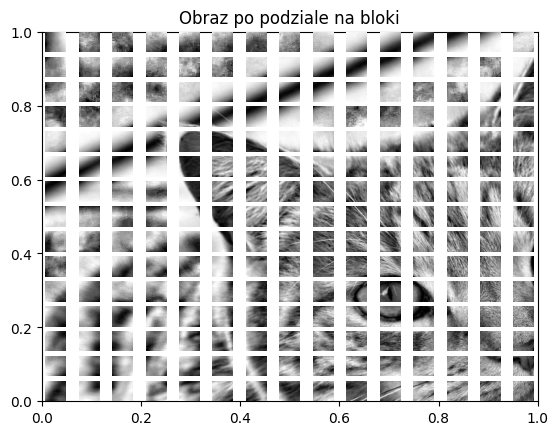

In [4]:
visualizations.show_blocks_grid(split_image)

### Algorytm DCT z wykorzystaniem biblioteki Scipy *(wersja podstawowa)*

#### `scipy_dct`

Jest to algorytm **2-DCT-2D** zaimplementowany z wykorzystaniem gotowej funkcji z biblioteki **SciPy**. Kluczową różnicą w stosunku do implementacji *from scratch* jest obsługa bloków prostokątnych ($M \neq N$), co umożliwia przetwarzanie obrazów o wymiarach niebędących wielokrotnościami tej samej potęgi dwójki.

In [6]:
def scipy_dct(split_image, img_h, img_w):
 with np.printoptions(edgeitems = 8, precision = 2, linewidth = 1000):
  B = dct(dct(split_image, axis=0, norm='ortho'), axis=1, norm='ortho')
  with np.printoptions(edgeitems=8, precision=1, linewidth=1000):
    if(img_h == 0 and img_w == 0):
      print(B)
  M, N = calculate_image_dimensions(split_image)
  mask = calculate_compression_mask(M, N)
  B_compressed = B * mask
  A_compressed = idct(idct(B_compressed, axis=0, norm='ortho'), axis=1, norm='ortho')
  return A_compressed

#### `apply_scipy_dct_to_all_blocks`

Odpowiednik funkcji `apply_dct_to_all_blocks` dostosowany do wersji bibliotecznej algorytmu. Obsługuje bloki prostokątne i zwraca obraz złożony z bloków przetworzonych przez `scipy_dct`.

In [9]:
def apply_scipy_dct_to_all_blocks(split_image):
  img_h, img_w = calculate_image_dimensions(split_image)
  image_combined = np.zeros_like(split_image)
  for i in range(img_h):
    for j in range(img_w):
      image_block = scipy_dct(split_image[i,j], i, j)
      image_combined[i, j] = image_block
  return image_combined

### Algorytm DCT from scratch (*wersja rozszerzona*)
1. **Transormata 2-DCT-2D:** Podwójna transformata 2-DCT-1D zrealizowana z wykorzystaniem macierzy współczynników ($T$ oraz $T^T$).
2. **Kwantyzacja:** Realizowana za pomocą dynamicznej maski, obliczanej na podstawie wymiarów bloku.
3. **Odwrócenie transformaty**: Realizowane za pomocą funkcji przeciwnej do Transformaty 2-DCT-2D.
<p style='text-align: justify;'><i>Funkcja odpowiada za zamiane sposobu zapisu obrazka z bloków na częstotliwości ortogonalne oraz kwantyzację i odwrócenie transformacji, wzór oraz zasada działania funkcji zostały opisane poniżej. Kod został zoptymalizowany i przystosowany do obliczeń macierzowych z wykrozystaniem biblioteki numpy, ze względu na szybkość wykonywania operacji na macierzach w porównaniu do klasycznych zagnieżdżonych pętli.</i></p>


#### Równanie transformacji DCT (2D-DCT-2): 
$$B_{pq} = \sum_{m=0}^{M-1} \sum_{n=0}^{N-1} \alpha_p \alpha_q A_{mn} \cos \frac{\pi(2m + 1)p}{2M} \cos \frac{\pi(2n + 1)q}{2N} = \sum_{m=0}^{M-1} \sum_{n=0}^{N-1} A_{mn} \alpha_p \cos \frac{\pi(2m + 1)p}{2M} \alpha_q \cos \frac{\pi(2n + 1)q}{2N}, \quad \begin{matrix} 0 \le m \le M-1 \\ 0 \le n \le N-1 \end{matrix}$$
<br>

Dla obrazów, których blok jest macierzą kwadratową ($M = N$), transformację tę można zapisać w wydajnej formie macierzowej. Definiując macierz bazową $T$ jako:
$$T_{pm} = \alpha_p \cos \frac{\pi(2m + 1)p}{2M}$$

<br>
Otrzymujemy postać macierzową stosowaną w kodzie:
$$B = T \cdot A \cdot T^T$$

Współczynniki wagowe są zdefiniowane jako:
$$\alpha_p = \begin{cases} 1/\sqrt{M}, & p = 0 \\ \sqrt{2/M}, & 1 \le p \le M-1 \end{cases} \quad \alpha_q = \begin{cases} 1/\sqrt{N}, & q = 0 \\ \sqrt{2/N}, & 1 \le q \le N-1 \end{cases}$$
<br>

In [7]:
def dct_compression(split_image, img_h, img_w):
  img_block = split_image[img_h, img_w]
  M, N = calculate_image_dimensions(img_block)
  PI = np.pi

  m = np.arange(M)
  p = np.arange(M)
  m = np.reshape(m, (1, -1))
  p = np.reshape(p, (-1, 1))
  
  T = np.cos((PI * (2*m+1) * p) / (2*M))
  T[0, :] /= np.sqrt(M)         
  T[1:, :] /= np.sqrt(M / 2)
  B = (T @ img_block @ T.T)

  with np.printoptions(edgeitems=8, precision=1, linewidth=1000):
    if(img_h == 0 and img_w == 0):
      print(B)
  
  mask = calculate_compression_mask(M,N)
  B_masked = B * mask
  A_compressed = T.T @ B_masked @ T
  return A_compressed

#### `apply_dct_to_all_blocks`

Funkcja iteruje po wszystkich blokach obrazu, wywołując na każdym z nich `dct_compression`, a następnie scala wyniki w jedną macierz o oryginalnych wymiarach. Umożliwia tym samym wizualizację efektu kompresji na całym obrazie.

In [8]:
def apply_dct_to_all_blocks(split_image):
  img_h, img_w = calculate_image_dimensions(split_image)
  image_combined = np.zeros_like(split_image)
  for i in range(img_h):
    for j in range(img_w):
      image_block = dct_compression(split_image, i, j)
      image_combined [i, j] = image_block
  return image_combined 

### Algorytm FFT z wykorzystaniem biblioteki NumPy

<p style='text-align: justify;'>
Jest to algorytm <b>2D-DFT</b> zaimplementowany z wykorzystaniem szybkiej transformaty Fouriera (<b>FFT</b>) z biblioteki NumPy.
Kluczową cechą tej implementacji jest progowanie amplitudowe z parametrem <b>M</b>:
wszystkie składowe częstotliwościowe, których amplituda jest niższa od wartości progowej, zostają wyzerowane bezpośrednio
w dziedzinie liczb zespolonych. Operacja ta stanowi uproszczoną formę kwantyzacji i jest tym bardziej stratna,
im niższy próg zostanie przyjęty.
</p>

In [10]:
def numpy_fft(cropped_image, M):
  Transformation = np.fft.fft2(cropped_image)
  mask = np.abs(Transformation) >= M
  Transformation_compressed = Transformation * mask
  fft_image = np.real(np.fft.ifft2(Transformation_compressed))
  return fft_image

### Algorytm SFT (*wersja rozszerzona*)

1. **Permutacja sygnału:** Wejściowy sygnał $x[n]$ jest pseudolosowo permutowany za pomocą parametru $\sigma$, co rozkłada częstotliwości równomiernie między kubełki (ang. *buckets*).
2. **Filtrowanie pasmowe:** Na spermutowany sygnał nakładany jest filtr pasmowy $G$, który przepuszcza jedynie okno $B$ częstotliwości na raz, tłumiąc pozostałe.
3. **Podpróbkowanie (subsampling):** Wyfiltrowany sygnał jest próbkowany co $N/B$ próbek, co redukuje jego długość z $N$ do $B$.
4. **FFT na podpróbkowanym sygnale:** Na krótkim sygnale długości $B$ wykonywana jest klasyczna FFT, dając przybliżone wartości dominujących współczynników w danym kubełku.
5. **Identyfikacja dominujących częstotliwości:** Spośród wyników FFT wybierane są składowe o amplitudzie powyżej progu energetycznego — kandydaci na elementy zbioru $\mathcal{S}_k$.
6. **Estymacja współczynników:** Dla każdej zidentyfikowanej częstotliwości $f^*$ wyznaczana jest jej dokładna wartość $\hat{x}[f^*]$ poprzez uśrednienie próbek fazowych.
7. **Odejmowanie i iteracja (peeling):** Znalezione składowe są odejmowane od sygnału wejściowego, a kroki 1–6 są powtarzane aż do wyznaczenia wszystkich $k$ dominujących współczynników.

<p style='text-align: justify;'><i>Funkcja odpowiada za wyodrębnienie k najsilniejszych częstotliwościowo składowych sygnału bez konieczności obliczania pełnego spektrum. Kluczową ideą jest to, że zamiast przetwarzać cały sygnał o długości N, algorytm wielokrotnie losowo permutuje i filtruje sygnał, sprowadzając problem do serii małych FFT o długości B ≪ N. Kod zoptymalizowany jest pod kątem rzadkości widma — im mniej dominujących składowych (mniejsze k), tym szybsze działanie algorytmu.</i></p>

#### Permutacja sygnału:

$$x_\sigma[n] = x\!\left[\sigma \cdot n \bmod N\right], \quad \sigma \in \mathbb{Z}_N^*$$

Permutacja w dziedzinie czasu odpowiada przesunięciu w dziedzinie częstotliwości:

$$\hat{x}_\sigma[f] = \hat{x}\!\left[\sigma^{-1} \cdot f \bmod N\right]$$

#### Filtrowanie i podpróbkowanie:

Sygnał po permutacji jest mnożony przez okno filtru $G[n]$ (np. płaskogórne), a następnie próbkowany co $N/B$ próbek:

$$z[j] = \left(x_\sigma \cdot G\right)\!\left[j \cdot \tfrac{N}{B}\right], \qquad j = 0, 1, \ldots, B-1$$

#### FFT na podpróbkowanym sygnale:

$$\hat{z}[b] = \sum_{j=0}^{B-1} z[j]\; e^{-i 2\pi b j / B}, \qquad b = 0, 1, \ldots, B-1$$

Każdy kubełek $b$ agreguje energię z grupy $N/B$ oryginalnych częstotliwości. Dominujące składowe wyróżniają się amplitudą ponad próg $\tau$:

$$\mathcal{S}_k = \left\{\, f^* : \left|\hat{z}[b(f^*)]\right| \geq \tau \,\right\}, \qquad |\mathcal{S}_k| = k$$

#### Współczynniki sparametryzowane są jako:

$$\hat{x}[f^*] \approx \frac{1}{T} \sum_{t=0}^{T-1} x\!\left[n_t\right]\, e^{i 2\pi f^* n_t / N}$$

gdzie $n_t$ to losowo dobrane punkty próbkowania używane do estymacji fazy i amplitudy każdej ze zidentyfikowanych częstotliwości $f^* \in \mathcal{S}_k$.
sft_opis.md
sft_opis.md (4 KB)
4 KB

In [ ]:
import numpy as np

def sft(cropped_image, keep_fraction=0.05):
  H, W = cropped_image.shape
  k = max(int(H * W * keep_fraction), 1)
  
  n_buckets = max(4 * k, 64)
  n_buckets = int(2 ** np.ceil(np.log2(n_buckets)))
  n_iterations = 3
  tolerance = 1e-6
  
  rng = np.random.default_rng(42)
  a = int(rng.integers(1, max(H // 2, 2)) * 2 + 1)
  b = int(rng.integers(0, H))
  row_perm = (a * np.arange(H) + b) % H
  col_perm = (a * np.arange(W) + b) % W
  permuted = cropped_image[np.ix_(row_perm, col_perm)]
  
  residual_spectrum = np.fft.fft2(permuted)
  found_freqs = {}
  
  per_iter = max(k // n_iterations, 1)
  stride_h = max(H // n_buckets, 1)
  stride_w = max(W // n_buckets, 1)
  
  for _ in range(n_iterations):
    if len(found_freqs) >= k: break
    
    bucket_spectrum = sft_hash_to_buckets(np.fft.ifft2(residual_spectrum).real, n_buckets)
    power = np.abs(bucket_spectrum) ** 2
    max_power = power.max()
    if max_power == 0: break
    threshold = tolerance * max_power
    
    candidates =[]
    active_buckets = np.argwhere(power > threshold)
    
    for bh, bw in active_buckets:
      fh_start, fw_start = int(bh) * stride_h, int(bw) * stride_w
      fh_range = range(fh_start, min(fh_start + stride_h, H))
      fw_range = range(fw_start, min(fw_start + stride_w, W))
      
      for fh in fh_range:
        for fw in fw_range:
          if (fh, fw) not in found_freqs:
            p = abs(residual_spectrum[fh, fw]) ** 2
            candidates.append((p, fh, fw))
            
    candidates.sort(key=lambda x: -x[0])
    new_count = 0
    for p, fh, fw in candidates:
      if len(found_freqs) >= k or new_count >= per_iter: break
      if (fh, fw) in found_freqs: continue
      
      found_freqs[(fh, fw)] = residual_spectrum[fh, fw]
      residual_spectrum[fh, fw] = 0.0 
      new_count += 1
      
  if len(found_freqs) < k:
    magnitudes = np.abs(residual_spectrum)
    flat_idx = np.argsort(magnitudes, axis=None)[::-1]
    for idx in flat_idx:
      if len(found_freqs) >= k: break
      fh, fw = np.unravel_index(idx, (H, W))
      if (fh, fw) not in found_freqs:
        found_freqs[(fh, fw)] = residual_spectrum[fh, fw]
        
  sparse_spectrum = np.zeros((H, W), dtype=complex)
  for (fh, fw), val in found_freqs.items():
    sparse_spectrum[fh, fw] = val
    
  permuted_recon = np.fft.ifft2(sparse_spectrum).real
  
  inv_row = np.argsort((a * np.arange(H) + b) % H)
  inv_col = np.argsort((a * np.arange(W) + b) % W)
  reconstructed = permuted_recon[np.ix_(inv_row, inv_col)]
  
  return np.clip(reconstructed, 0, 255)

def sft_hash_to_buckets(signal_2d, n_buckets):
  H, W = signal_2d.shape
  stride_h = max(H // n_buckets, 1)
  stride_w = max(W // n_buckets, 1)
  subsampled = signal_2d[::stride_h, ::stride_w]
  return np.fft.fft2(subsampled)

<div style="background:#fef2f2; border-left:5px solid #ef4444; border-radius:8px; padding:16px 20px; margin:8px 0;">
<strong>⚠️ Uwaga autorska</strong><br><br>
Panie ledwo to działa, no ale gemini płakał jak generował my płaczemy jak widzimy jak ten algorytm działa z plusów jest najwolniejszy ze wszytskich zużywa 20 GB Ramu i daje najgorsze efekty wizualne, plusów ujemnych brak.
</div>

### Wizualizacja zmian w obrazie

Poniżej przedstawiono zestawienie czterech obrazów: oryginału oraz wyników kompresji algorytmami **DCT** *(from scratch)*, **DCT** *(SciPy)*, **FFT** i **SFT**. Wizualizacja pozwala ocenić subiektywną jakość rekonstrukcji i porównać widoczne artefakty kompresji.

In [11]:
dct_compressed_image = dct.apply_dct_to_all_blocks(split_image)
dct_image = dct.merge_blocks_into_image(dct_compressed_image, dct_block_size)
scipy_dct_compressed_image = dct.apply_scipy_dct_to_all_blocks(split_image)
scipy_dct_image = dct.merge_blocks_into_image(scipy_dct_compressed_image, dct_block_size)
fft_image = fft.numpy_fft(cropped_image, 50)
sft_image = sft.sft(cropped_image, keep_fraction=0.01)

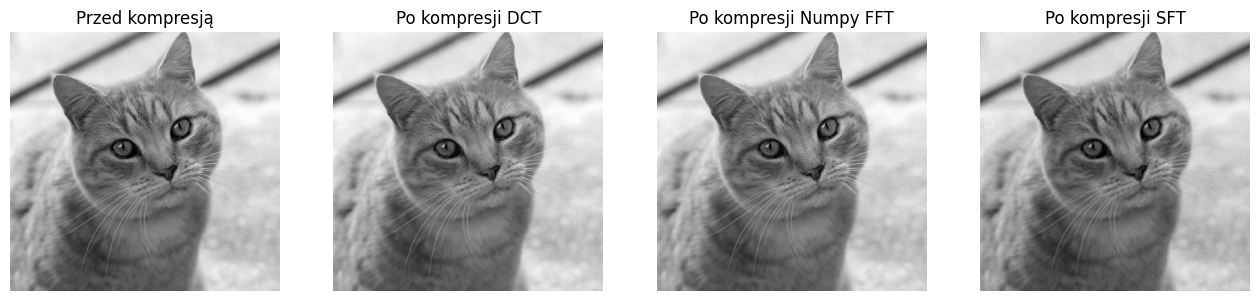

In [12]:
visualizations.show_decompression_efect(cropped_image, dct_image, fft_image, sft_image)

---
## CELpeg *(Compressed with Elegance Lite)*

Własny format zapisu obrazu skompresowanego algorytmem **DCT**. Plik wynikowy zawiera nagłówek z wymiarami obrazu oraz rozmiarem bloku, co umożliwia odtworzenie obrazu bez dodatkowych metadanych. Format pełni rolę demonstracyjną — ilustruje ideę binarnego zapisu skompresowanego sygnału.

### Obraz po dekompresji

Obraz odtworzony z pliku **CELpeg** poprzez wczytanie nagłówka, odbudowę bloków i zastosowanie odwrotnej **IDCT**.

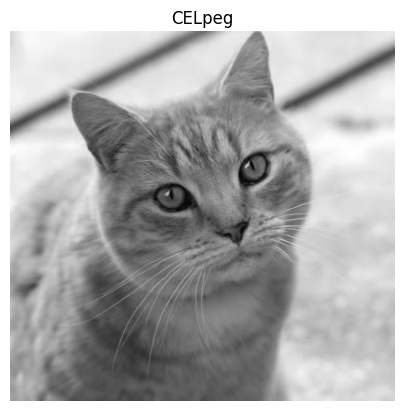

In [13]:
dct_format.save_dct_image_to_file(split_image)

---
## Porównanie metryk jakości kompresji

### SNR *(Signal-to-Noise Ratio)*

**SNR** jest jedną z podstawowych miar jakości obrazu skompresowanego względem oryginału. Obliczany jest ze wzoru:

$$SNR = 10 \cdot \log_{10}\left(\frac{\sum f(x,y)^2}{\sum (f(x,y) - \hat{f}(x,y))^2}\right)$$

gdzie $f(x,y)$ oznacza obraz oryginalny, a $\hat{f}(x,y)$ obraz po kompresji i rekonstrukcji. Licznik to energia sygnału oryginalnego, mianownik — energia błędu rekonstrukcji. Wynik wyrażany jest w **decybelach (dB)**.

> **Interpretacja:** im wyższa wartość SNR, tym obraz bliższy oryginałowi (kompresja mniej stratna). Im wartość bliższa zeru, tym większa utrata informacji.

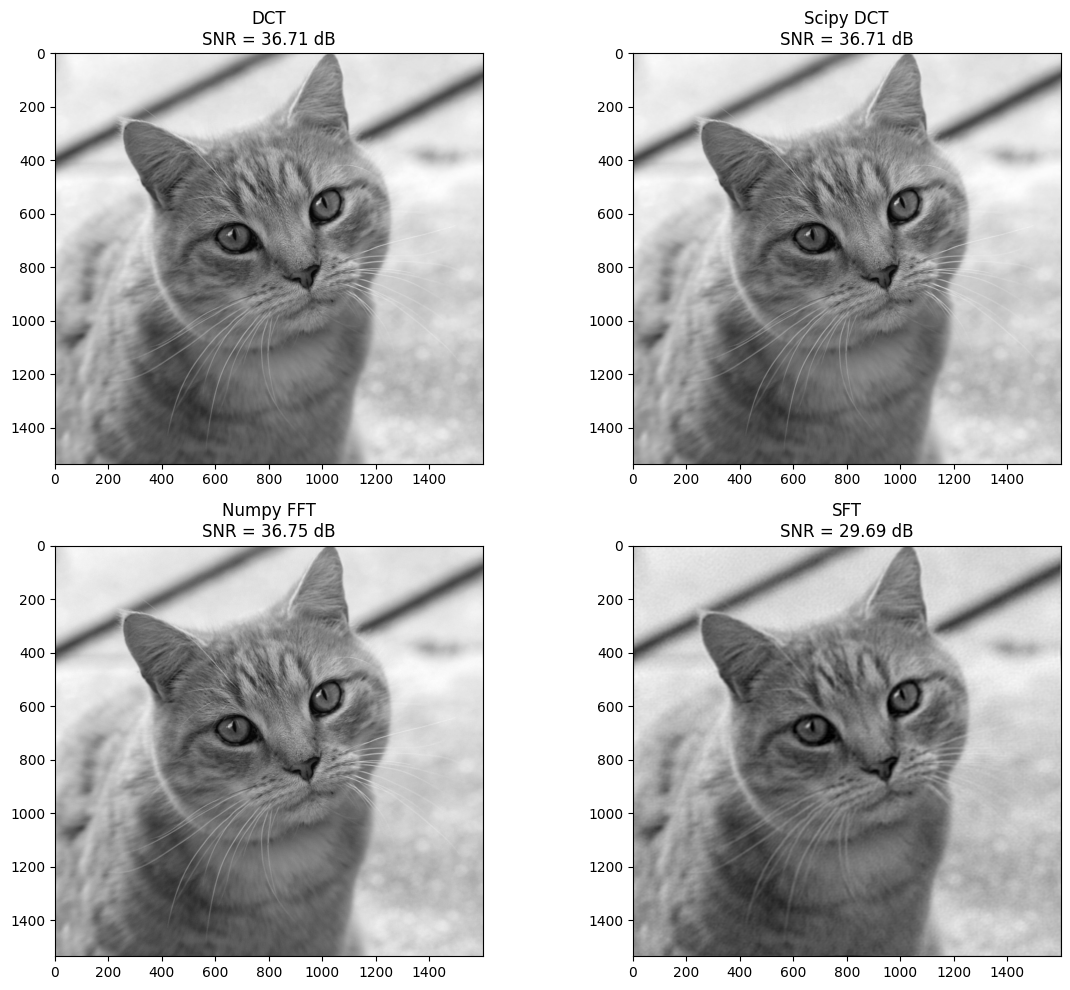

In [14]:
visualizations.show_snr(cropped_image, dct_image, scipy_dct_image, fft_image, sft_image)

---
### Błąd aproksymacji

<p style='text-align: justify;'>
Wykres prezentuje <b>błąd aproksymacji</b> $\varepsilon^2(M)$ w skali logarytmicznej dla transformacji <b>DCT</b> i <b>FFT</b>
w funkcji liczby zachowanych współczynników $M$.
</p>

Błąd aproksymacji wyraża się wzorem:

$$\varepsilon^2(M) = \|f - f_M\|^2 = \sum_{k \notin \mathcal{S}_M} |\hat{f}_k|^2$$

gdzie $f_M$ to rekonstrukcja obrazu oparta wyłącznie na $M$ dominujących współczynnikach ze zbioru $\mathcal{S}_M$, a $\hat{f}_k$ to $k$-ty współczynnik transformaty.

<p style='text-align: justify;'>
Im więcej współczynników zostaje zachowanych, tym mniejszy jest błąd rekonstrukcji.
Nachylenie krzywej na wykresie logarytmicznym odzwierciedla <b>szybkość skupiania energii</b> danej transformaty:
im szybciej krzywa opada ku zeru, tym dana baza ortogonalna efektywniej reprezentuje strukturę obrazu
przy mniejszej liczbie składowych — co przekłada się bezpośrednio na wyższą wydajność kompresji.
</p>

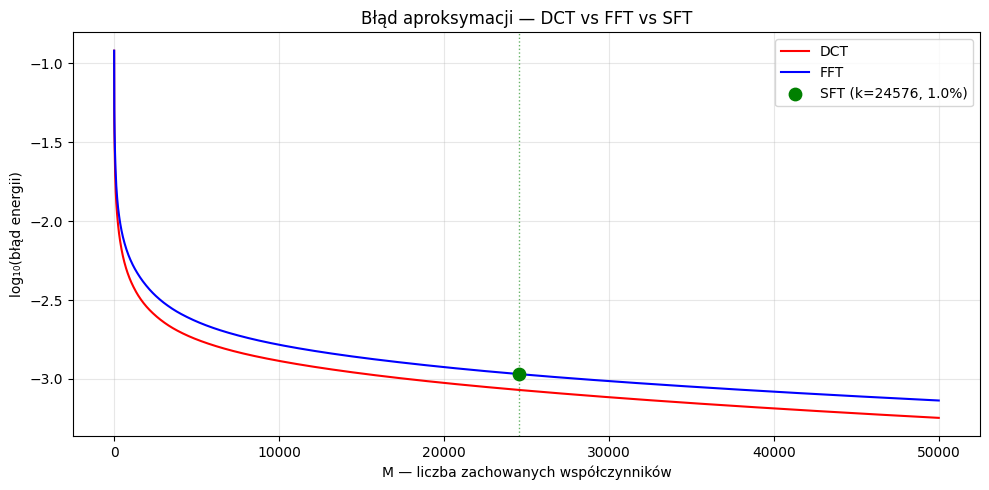

In [15]:
visualizations.show_correlation(cropped_image)

---
## Zobrazowanie współczynników kompresji

Poniższe macierze wizualizują rozkład energii w dziedzinie częstotliwościowej dla obu algorytmów. Jasność punktu odpowiada amplitudzie danego współczynnika — im jaśniej, tym większy wkład tej składowej w sygnał.

<table style="width:100%; border-collapse:collapse; margin-top:10px;">
<tr>
<td style="padding:12px; vertical-align:top; width:50%;">
<strong>DCT (Scipy)</strong><br>
Energia skupiona jest w <b>lewym górnym rogu</b> macierzy, co odpowiada składowym o najniższych częstotliwościach
(ogólna jasność, łagodne przejścia tonalne). Wraz z przesuwaniem się w stronę prawego dolnego rogu amplitudy
maleją — odpowiadają tam za drobne detale i szumy. Takie <em>upakowanie energii</em> w jednym narożniku
jest fundamentem wydajnej kompresji DCT: wystarczy wyzerować wartości poniżej progu kwantyzacji,
aby znacznie zmniejszyć rozmiar danych przy minimalnej widocznej stracie jakości.
</td>
<td style="padding:12px; vertical-align:top; width:50%;">
<strong>FFT (NumPy)</strong><br>
W standardowym układzie wyjściowym FFT energia <b>nie jest skupiona w jednym rogu</b>, lecz rozłożona
symetrycznie w czterech narożnikach macierzy. Wynika to z periodyczności sygnału zakładanej przez FFT
(zjawisko <em>circular convolution</em>) — najniższe częstotliwości trafiają na krawędzie, a nie do środka.
Taki rozkład jest mniej ergonomiczny dla kompresji w porównaniu z DCT, choć po zastosowaniu
<code>np.fft.fftshift</code> energia skupia się w centrum.
</td>
</tr>
</table>

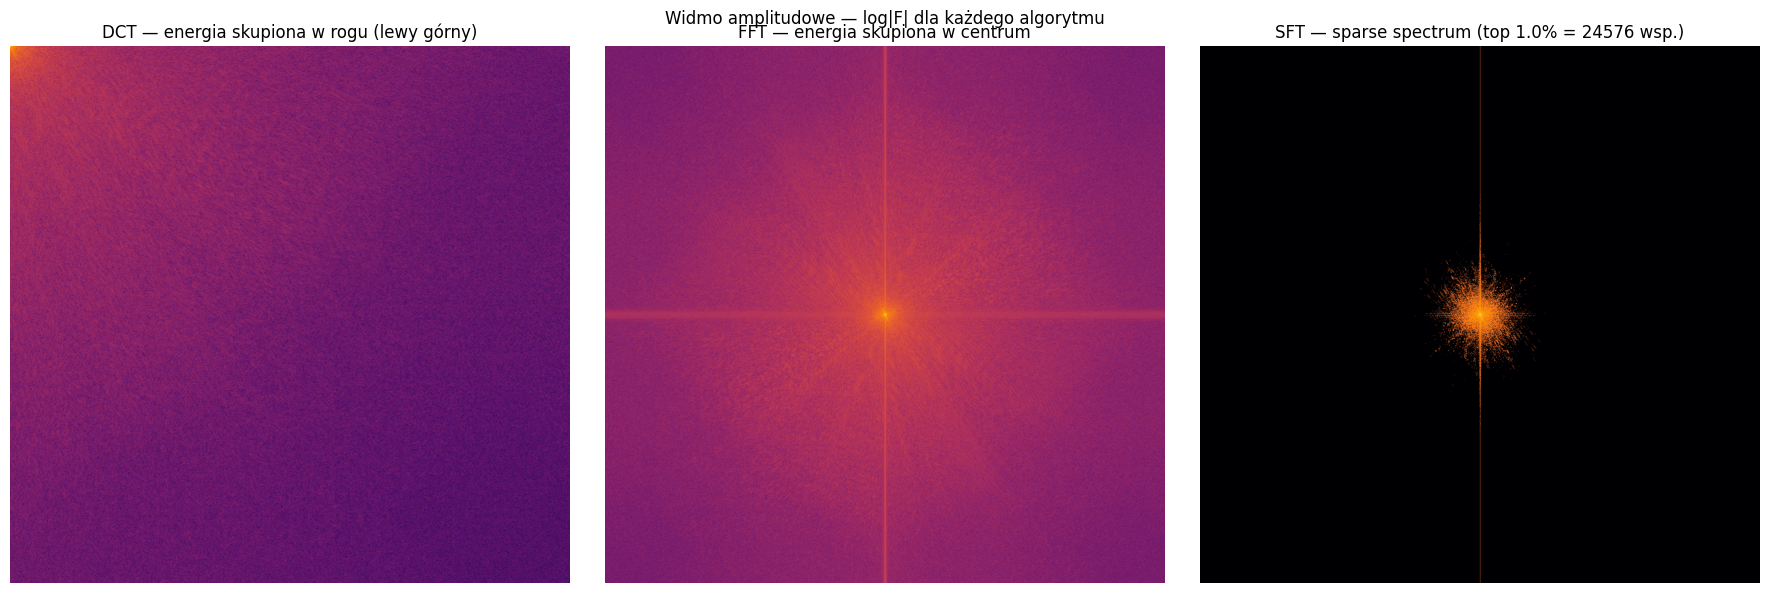

In [16]:
visualizations.show_coeffcients(cropped_image)

---
### Porównanie czasów kompresji dla wybranego modelu testowego

Wykres słupkowy prezentuje średni czas wykonania każdego z algorytmów na tym samym obrazie testowym. Pozwala to ocenić koszt obliczeniowy każdej metody niezależnie od miar jakości.

In [17]:
times = np.zeros((4,1))
times[0] = time_measure.time_dct(split_image, dct_block_size)
times[1] = time_measure.time_scipy_dct(split_image, dct_block_size)
times[2] = time_measure.time_numpy_fft(cropped_image)
times[3] = time_measure.time_sft(cropped_image)

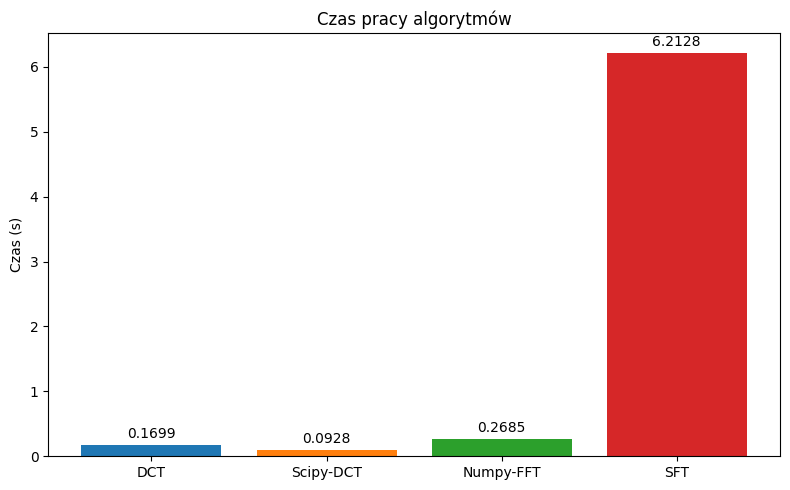

In [18]:
visualizations.show_time_chart(times)

---
### Porównanie metryk jakości

<p style='text-align: justify;'>
Metryki jakości to obiektywne miary liczbowe pozwalające porównać obraz skompresowany z oryginałem.
Każda z nich ujmuje jakość rekonstrukcji z nieco innej perspektywy — dlatego ich łączna analiza
daje pełniejszy obraz skuteczności danego algorytmu niż sama ocena wizualna.
</p>

W porównaniu stosowane są następujące metryki:

| Metryka | Pełna nazwa | Interpretacja |
|---|---|---|
| **MSE** | Mean Squared Error | Średni kwadrat różnicy pikseli; im bliżej 0, tym lepsza rekonstrukcja |
| **PSNR** | Peak Signal-to-Noise Ratio | Stosunek maksymalnej energii sygnału do energii błędu [dB]; wyższy = lepszy |
| **SSIM** | Structural Similarity Index | Miara podobieństwa strukturalnego (luminancja, kontrast, struktura); zakres $[-1, 1]$, im bliżej 1, tym lepiej |
| **SNR** | Signal-to-Noise Ratio | Stosunek energii sygnału do energii szumu [dB]; wyższy = lepsza jakość |

> **Uwaga praktyczna:** PSNR i SNR operują w skali decybelowej — wartości powyżej 30 dB uznawane są za akceptowalną jakość kompresji stratnej. SSIM jest natomiast bardziej zgodny z subiektywną oceną wzrokową, ponieważ uwzględnia lokalne struktury obrazu.

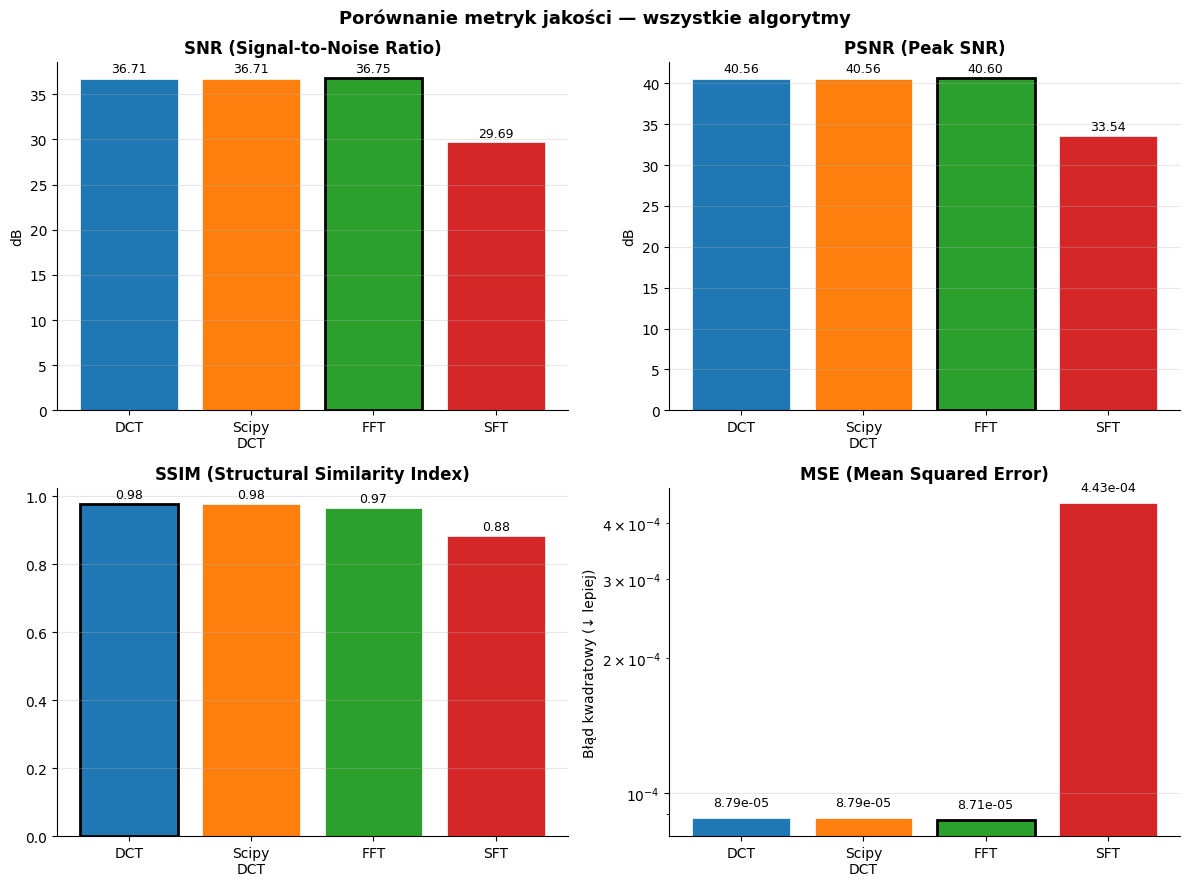

In [19]:
visualizations.show_metrics_comparison(cropped_image, dct_image, scipy_dct_image, fft_image, sft_image)

---
### Wykresy pojedynczej fazy dla algorytmów DCT, FFT oraz SFT

<p style='text-align: justify;'>
Wykres <b>pojedynczej fazy</b> (ang. <em>single-phase plot</em>) przedstawia wizualnie zrekonstruowany obraz
uzyskany przy użyciu wyłącznie jednej wybranej składowej częstotliwościowej transformaty.
Innymi słowy, zamiast sumować wszystkie współczynniki w celu pełnej rekonstrukcji, wyświetlamy wkład
jednej konkretnej fazy — co pozwala zobaczyć, jak poszczególne częstotliwości kształtują strukturę obrazu.
</p>

Interpretacja wykresu zależy od użytej transformaty:

- **DCT:** każda faza odpowiada jednemu wzorcowi cosinusoidalnemu rozłożonemu na blokach; niskie fazy
  (lewy górny róg) odpowiadają za ogólną jasność i łagodne przejścia, wysokie — za drobne krawędzie i tekstury.
- **FFT:** faza to składowa o konkretnej częstotliwości przestrzennej; wizualizacja ukazuje charakterystyczne
  prążki sinusoidalne w pionie, poziomie lub ukośnie w zależności od wybranego indeksu.
- **SFT:** ze względu na rzadkość reprezentacji, wykres pojedynczej fazy uwidacznia dominujące
  składowe widma — te, które algorytm uznał za wystarczająco energetyczne, aby je zachować.

> Parametr `n` przekazany do funkcji `show_phase_comparison` określa, która składowa jest wizualizowana.

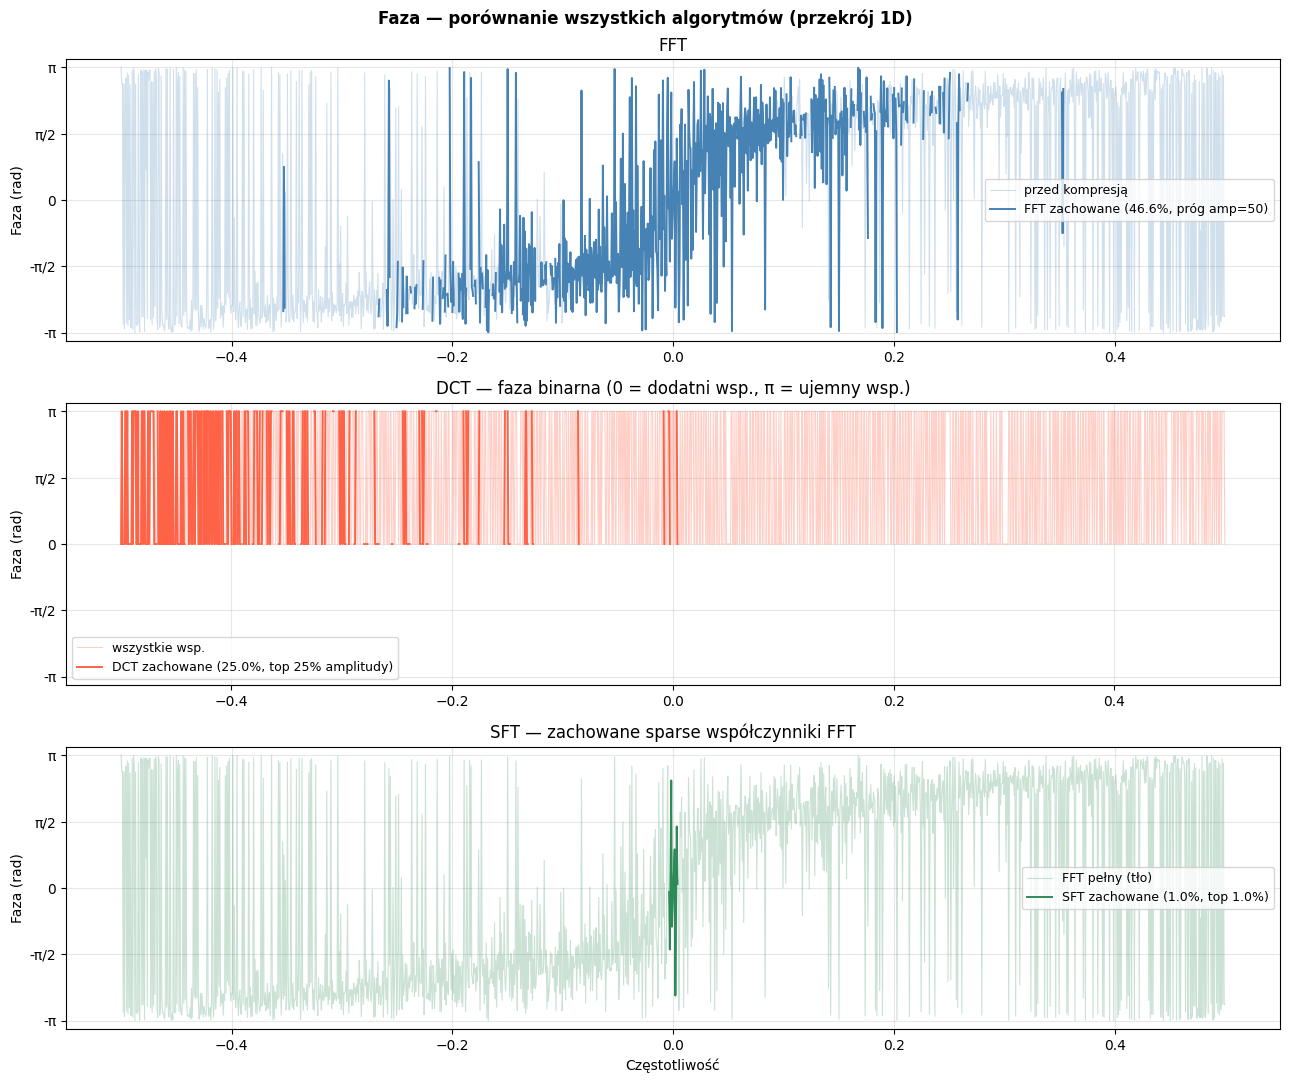

In [20]:
visualizations.show_phase_comparison(cropped_image, 50)

---
### Porównanie czasu wykonania algorytmu DCT w zależności od rozmiaru bloku

Wykres przedstawia czas kompresji algorytmem **DCT** *(from scratch)* dla różnych rozmiarów bloku na zestawie modeli testowych. Pozwala ocenić, jak rozmiar okna przetwarzania ($8\times8$, $16\times16$ itd.) wpływa na koszt obliczeniowy transformaty — większe bloki wymagają więcej operacji macierzowych, ale mogą osiągać lepszy współczynnik kompresji.

--- Benchmark dla: test_model.jpg ---
Postęp:  25% | Przetworzono 1/4 plików
--- Benchmark dla: test_model2.jpg ---
Postęp:  50% | Przetworzono 2/4 plików
--- Benchmark dla: test_model3.jpg ---
Postęp:  75% | Przetworzono 3/4 plików
--- Benchmark dla: test_model4.jpg ---
Postęp: 100% | Przetworzono 4/4 plików


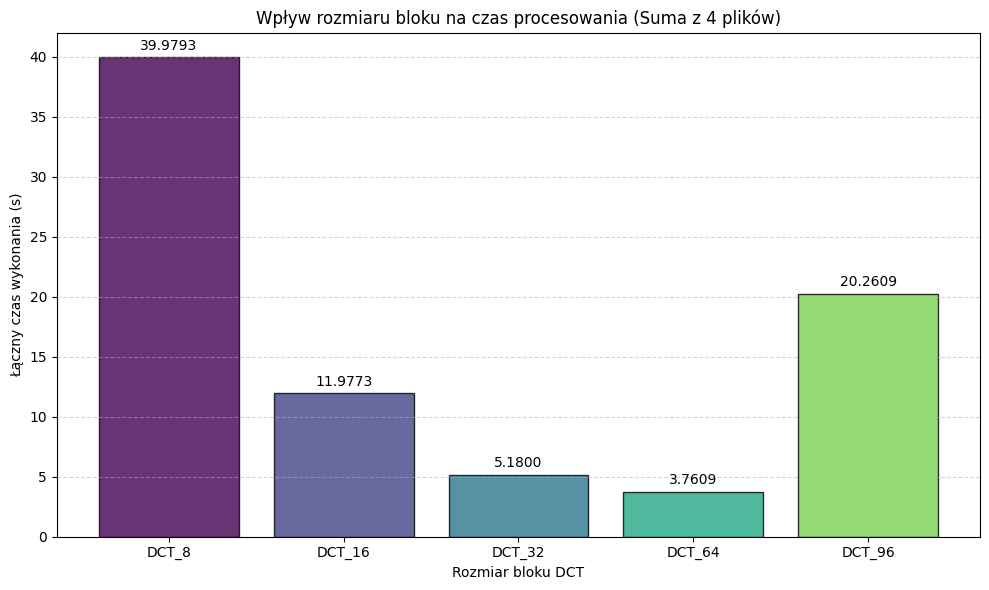

In [21]:
dct_benchmark_results = time_measure.dct_time_benchmark(files_path)
visualizations.show_dct_benchmark_chart(dct_benchmark_results)